<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytorch_metric_learning

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 28.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.2-py3-none-any.whl size=38334 sha256=887eedcae753cdd020ccdbc027b026ab765631fed7baf8823b1fa6057d478bfb
  Stored in directory: /root/.cache/pip/wheels/b4/68/bb/d10381e86dc0de1c9354bce3d86bffcd247305058c40ce2e55
Successfully built grad-cam


In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
zip_path = 'archive.zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 1'), transform=transform)
val_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 2'), transform=transform)
test_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 3'), transform=transform)

In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
model = models.alexnet(pretrained=True)
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(train_data.classes))

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:12<00:00, 20.3MB/s]


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(45):
    model.train()
    train_loss = 0
    train_acc = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds = outputs.argmax(dim=1)
        train_acc += accuracy_score(labels.cpu(), train_preds.cpu())

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_preds = outputs.argmax(dim=1)
            val_acc += accuracy_score(labels.cpu(), val_preds.cpu())

    print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_acc/len(train_loader)}')
    print(f'Epoch {epoch+1}, Validation Loss: {val_loss/len(val_loader)}, Validation Accuracy: {val_acc/len(val_loader)}')

model.eval()
test_acc = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_preds = outputs.argmax(dim=1)
        test_acc += accuracy_score(labels.cpu(), test_preds.cpu())

print(f'Test Accuracy: {test_acc/len(test_loader)}')

Epoch 1, Train Loss: 1.425202591078622, Train Accuracy: 0.3132440476190476
Epoch 1, Validation Loss: 1.7860164514609747, Validation Accuracy: 0.24553571428571427
Epoch 2, Train Loss: 1.2165888590472085, Train Accuracy: 0.45089285714285715
Epoch 2, Validation Loss: 1.2400386248316084, Validation Accuracy: 0.4069940476190476
Epoch 3, Train Loss: 1.0878539851733617, Train Accuracy: 0.4873511904761905
Epoch 3, Validation Loss: 1.2079241403511591, Validation Accuracy: 0.49107142857142855
Epoch 4, Train Loss: 1.005323486668723, Train Accuracy: 0.48660714285714285
Epoch 4, Validation Loss: 1.1815621427127294, Validation Accuracy: 0.42038690476190477
Epoch 5, Train Loss: 0.9592981295926231, Train Accuracy: 0.5446428571428571
Epoch 5, Validation Loss: 1.1473916939326696, Validation Accuracy: 0.4873511904761905
Epoch 6, Train Loss: 1.0678174878869737, Train Accuracy: 0.5171130952380952
Epoch 6, Validation Loss: 1.2145845485585076, Validation Accuracy: 0.5290178571428571
Epoch 7, Train Loss: 1.06

In [ ]:
def generate_gradcam(model, image, target_layer):
    if image.shape[0] != model.features[0].weight.shape[1]:
        image = image.repeat(model.features[0].weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [ ]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)
target_layer = model.features[0]
cam_image = generate_gradcam(model, image, target_layer)

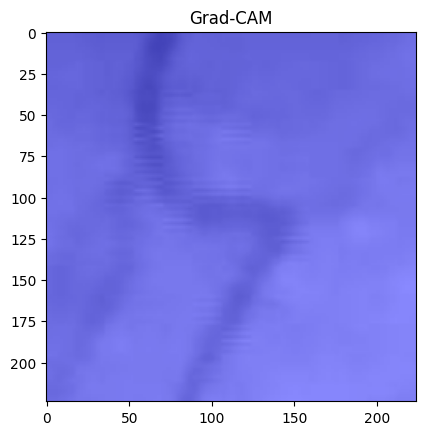

In [ ]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()